<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Introducción al Procesamiento Digital de Imágenes</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  5 de febrero de 2026
</p>


# **Filtrado de Imágenes en el Dominio Espacial**

## Convolución

In [1]:
import numpy as np

f = np.array([
    [2, 3, 0, 1, 2],
    [4, 6, 2, 1, 0],
    [3, 1, 5, 7, 2],
    [0, 2, 3, 6, 1],
    [1, 1, 0, 2, 4]
])

w = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

x_idx, y_idx = 2, 2  # índice Python para (3,3)

terms = []
for s in range(-1, 2):
    for t in range(-1, 2):
        w_val = w[s+1, t+1]
        f_val = f[x_idx - s, y_idx - t]
        prod = w_val * f_val
        terms.append((s, t, w_val, f_val, prod))

print("Detalle paso a paso de g(3,3):\n")
for s, t, wv, fv, p in terms:
    x_coord = 3 - s
    y_coord = 3 - t
    print(f"w({s:+d},{t:+d}) * f({x_coord},{y_coord}) = {wv:2d} * {fv:2d} = {p:+3d}")

print("\nOrganización 3x3 (fila por fila):")
for i in range(3):
    row = terms[i*3:(i+1)*3]
    row_str = "   ".join(f"{rw[2]:2d}*{rw[3]:2d}={rw[4]:+3d}" for rw in row)
    print(row_str)

total = sum(p for *_, p in terms)
print(f"\nSuma total: g(3,3) = {total:+d}")


Detalle paso a paso de g(3,3):

w(-1,-1) * f(4,4) =  0 *  6 =  +0
w(-1,+0) * f(4,3) =  1 *  3 =  +3
w(-1,+1) * f(4,2) =  0 *  2 =  +0
w(+0,-1) * f(3,4) =  1 *  7 =  +7
w(+0,+0) * f(3,3) = -4 *  5 = -20
w(+0,+1) * f(3,2) =  1 *  1 =  +1
w(+1,-1) * f(2,4) =  0 *  1 =  +0
w(+1,+0) * f(2,3) =  1 *  2 =  +2
w(+1,+1) * f(2,2) =  0 *  6 =  +0

Organización 3x3 (fila por fila):
 0* 6= +0    1* 3= +3    0* 2= +0
 1* 7= +7   -4* 5=-20    1* 1= +1
 0* 1= +0    1* 2= +2    0* 6= +0

Suma total: g(3,3) = -7


## Filtros de suavizado

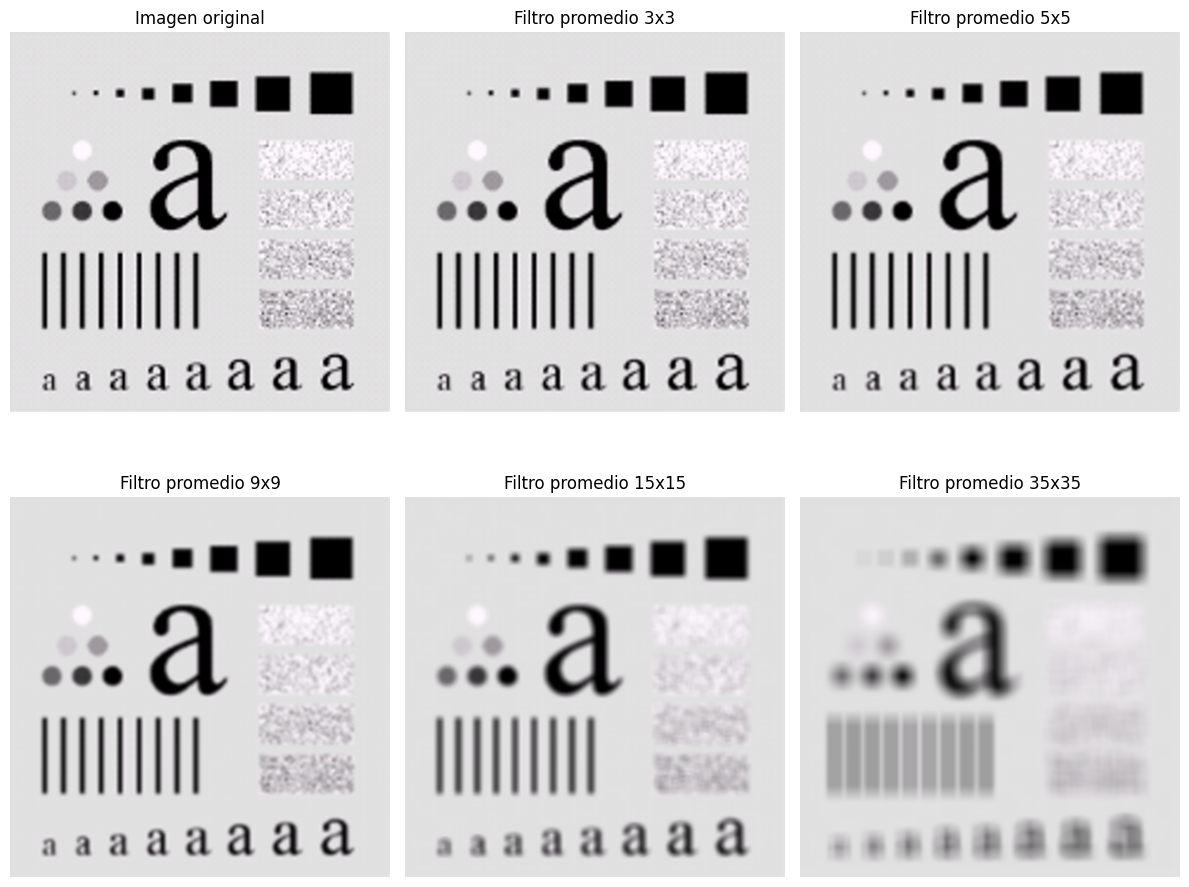

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- Cargar imagen ---
img_path = 'fig/Notebook/Ejemplo1.png'
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"No se encontró la imagen en la ruta: {img_path}")

# Convertir de BGR (OpenCV) a RGB (para matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Definir tamaños de ventana ---
kernel_sizes = [3, 5, 9, 15, 35]

# --- Aplicar filtros de suavizado ---
blurred_images = []
for k in kernel_sizes:
    blur = cv2.blur(img_rgb, (k, k))
    blurred_images.append(blur)

# --- Crear la figura con subplots ---
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.ravel()  # Aplanar arreglo 2D de ejes

# --- Mostrar la imagen original ---
axes[0].imshow(img_rgb)
axes[0].set_title("Imagen original")
axes[0].axis('off')

# --- Mostrar las imágenes suavizadas ---
for i, (k, blur) in enumerate(zip(kernel_sizes, blurred_images)):
    axes[i+1].imshow(blur)
    axes[i+1].set_title(f"Filtro promedio {k}x{k}")
    axes[i+1].axis('off')

# --- Ocultar el último subplot si no se usa ---
if len(kernel_sizes) + 1 < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


## Filtro Gaussiano

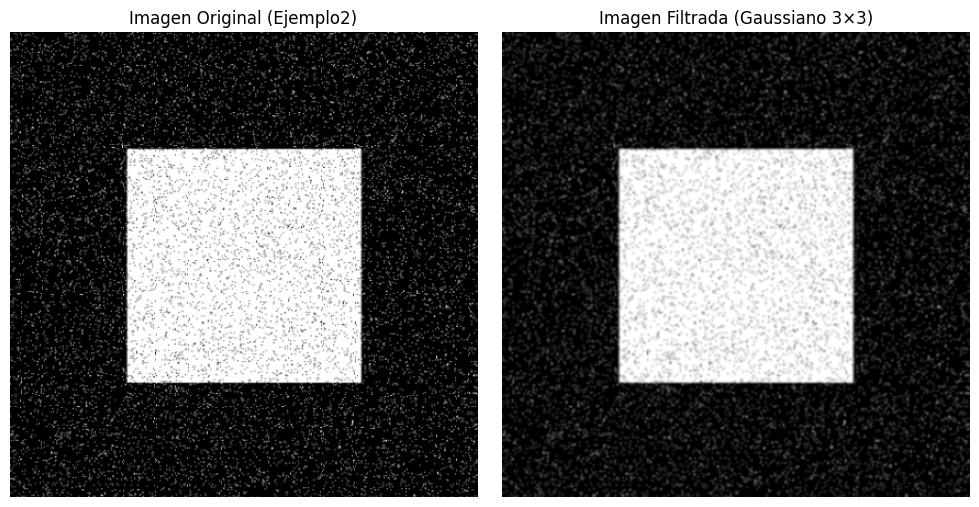

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Ejemplo2.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Definir la máscara gaussiana 3x3 ---
gaussian_kernel = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)

# --- Aplicar convolución con la máscara gaussiana ---
gaussian_filtered = cv2.filter2D(img, -1, gaussian_kernel)

# --- Mostrar resultados ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagen Original (Ejemplo2)")
axes[0].axis("off")

axes[1].imshow(gaussian_filtered, cmap='gray')
axes[1].set_title("Imagen Filtrada (Gaussiano 3×3)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


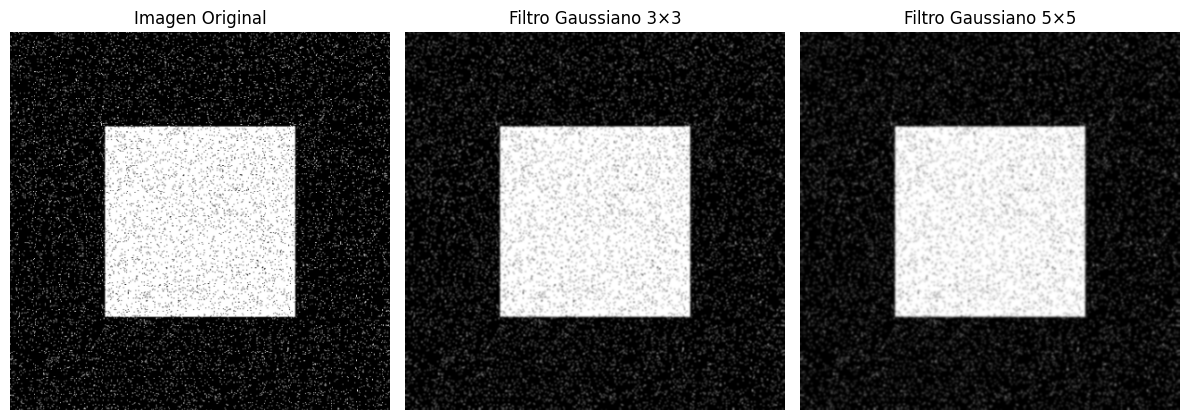

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Ejemplo2.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Máscara gaussiana 3x3 explícita ---
gaussian_kernel_3x3 = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)

# --- Filtro gaussiano 5x5 generado ---
# getGaussianKernel genera un vector 1D gaussiano, lo multiplicamos para formar el 2D
g1d = cv2.getGaussianKernel(5, sigma=1)
gaussian_kernel_5x5 = g1d @ g1d.T  # producto externo -> kernel 2D

# --- Aplicar los filtros ---
filtered_3x3 = cv2.filter2D(img, -1, gaussian_kernel_3x3)
filtered_5x5 = cv2.filter2D(img, -1, gaussian_kernel_5x5)

# --- Mostrar resultados ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

titles = [
    "Imagen Original",
    "Filtro Gaussiano 3×3",
    "Filtro Gaussiano 5×5"
]
images = [img, filtered_3x3, filtered_5x5]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


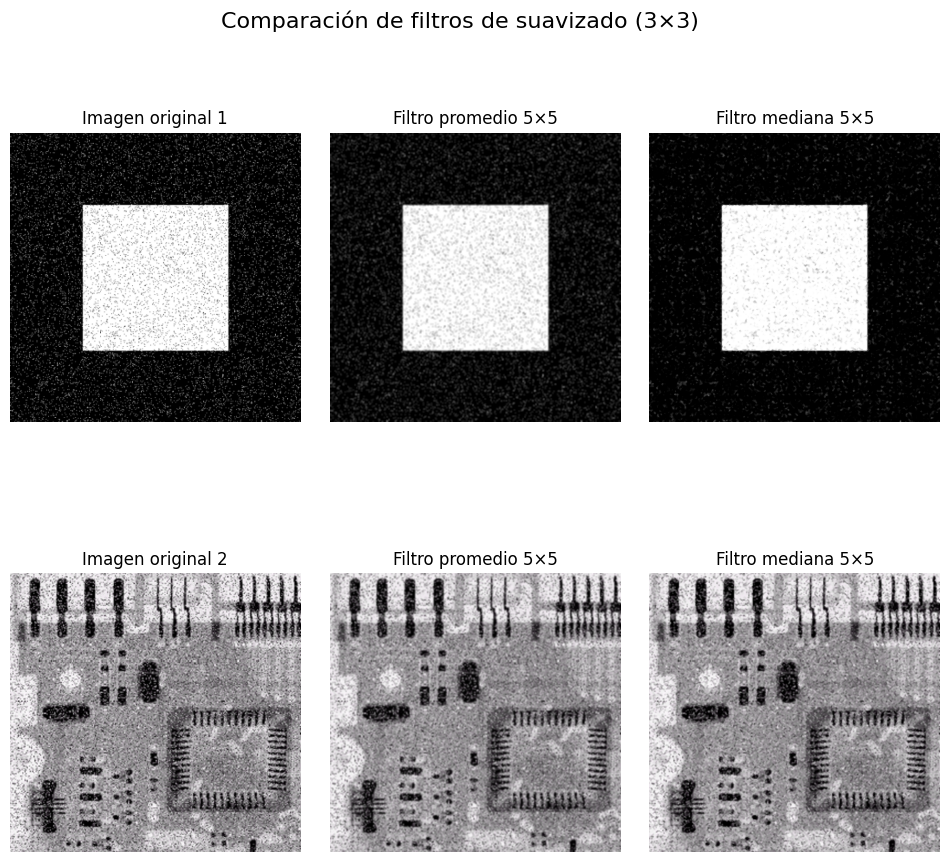

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- Rutas de las imágenes ---
image_paths = [
    'fig/Notebook/Ejemplo2.png',
    'fig/Notebook/Ejemplo3.png'
]

# --- Leer y convertir las imágenes a RGB ---
images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"No se encontró la imagen: {path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img_rgb)

# --- Aplicar filtros ---
mean_filtered = [cv2.blur(img, (3, 3)) for img in images]
median_filtered = [cv2.medianBlur(img, 3) for img in images]

# --- Crear figura con subplots 3x3 ---
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

titles = [
    "Imagen original", "Filtro promedio 5×5", "Filtro mediana 5×5"
]

# --- Mostrar resultados ---
for i in range(2):  # Una fila por imagen
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title(f"{titles[0]} {i+1}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mean_filtered[i])
    axes[i, 1].set_title(titles[1])
    axes[i, 1].axis('off')

    axes[i, 2].imshow(median_filtered[i])
    axes[i, 2].set_title(titles[2])
    axes[i, 2].axis('off')

plt.suptitle("Comparación de filtros de suavizado (3×3)", fontsize=16)
plt.show()


## Filtros derivativos
- Filtro Laplaciano

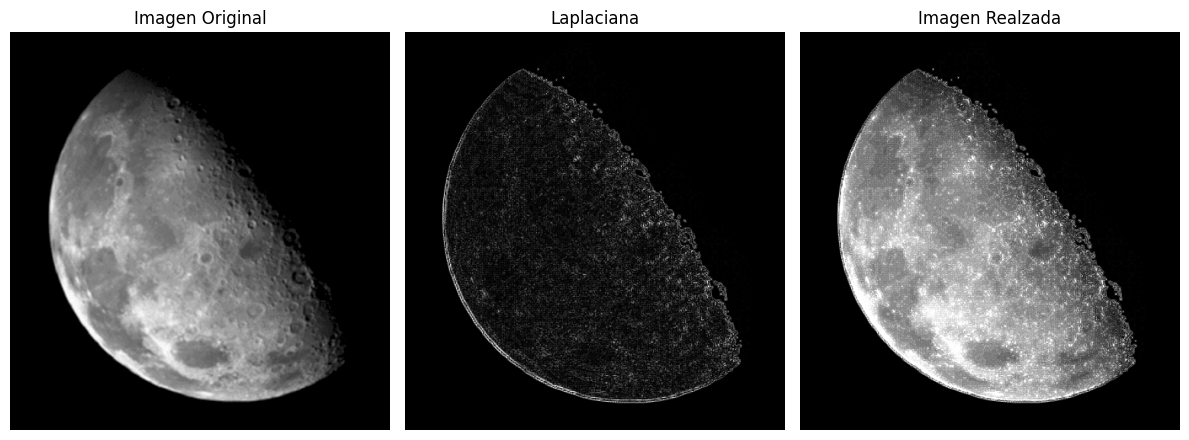

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Luna.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Calcular Laplaciana ---
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
laplacian = cv2.convertScaleAbs(laplacian)

# --- Realce: sumar la Laplaciana a la imagen original ---
realzada = cv2.addWeighted(img, 1.0, laplacian, 1.0, 0)

# --- Mostrar resultados ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
titles = ['Imagen Original', 'Laplaciana', 'Imagen Realzada']

for ax, im, title in zip(axes, [img, laplacian, realzada], titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


## Filtro de Sobel

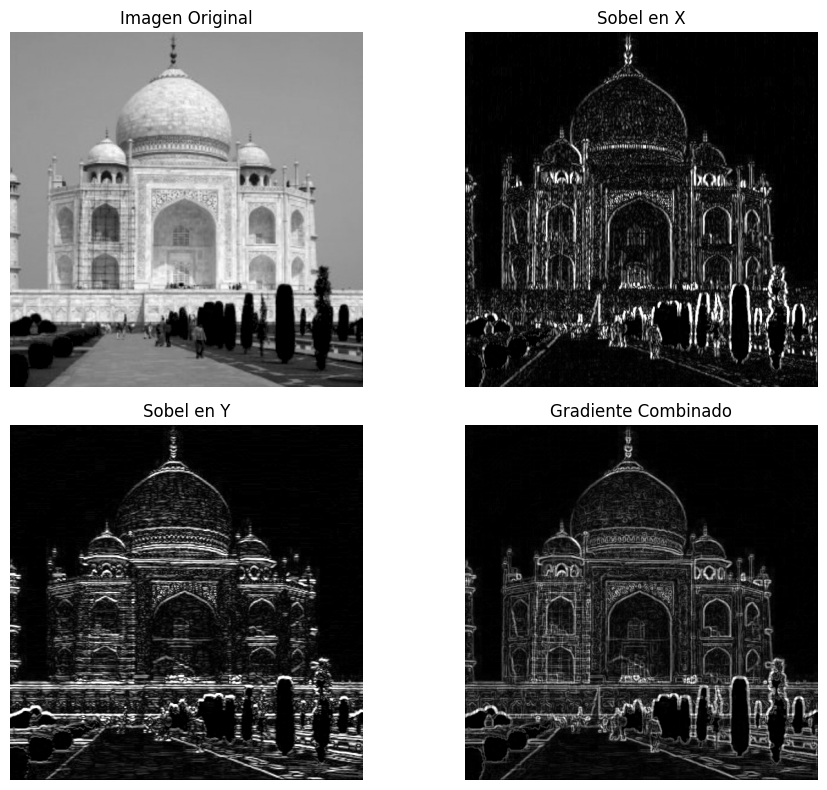

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Mezquita.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Aplicar filtro de Sobel ---
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Convertir a escala de 8 bits para visualización
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)

# Magnitud del gradiente (combinación de ambos)
sobel_combined = cv2.addWeighted(sobelx_abs, 0.5, sobely_abs, 0.5, 0)

# --- Mostrar resultados ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
titles = [
    'Imagen Original',
    'Sobel en X',
    'Sobel en Y',
    'Gradiente Combinado'
]
images = [img, sobelx_abs, sobely_abs, sobel_combined]

for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


## Filtro de Canny

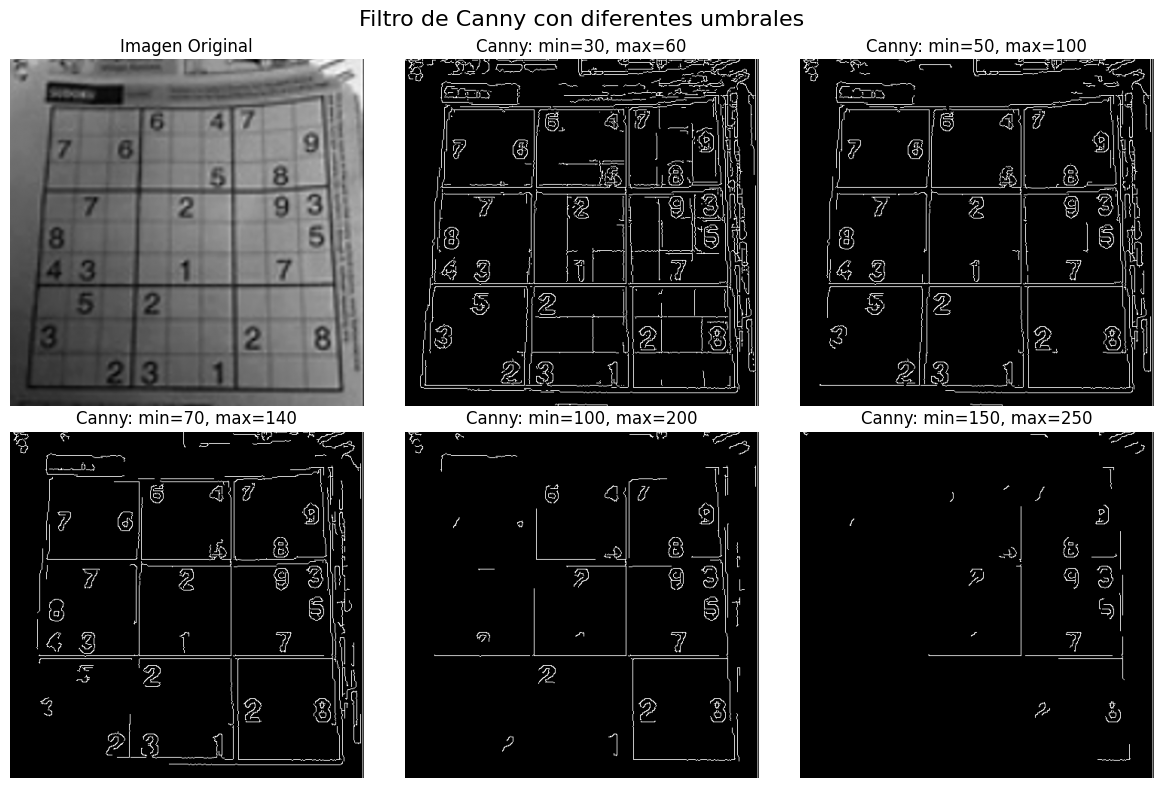

In [8]:
import cv2
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Sudoku.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Definir combinaciones de umbrales (min, max) ---
thresholds = [
    (30, 60),
    (50, 100),
    (70, 140),
    (100, 200),
    (150, 250)
]

# --- Aplicar Canny ---
edges = [cv2.Canny(img, t1, t2) for (t1, t2) in thresholds]

# --- Crear figura 2x3 ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Primera imagen: original
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

# Siguientes imágenes: resultados Canny
for ax, edge_img, (t1, t2) in zip(axes.flat[1:], edges, thresholds):
    ax.imshow(edge_img, cmap='gray')
    ax.set_title(f'Canny: min={t1}, max={t2}')
    ax.axis('off')

# Quitar subplots vacíos si los hubiera
for ax in axes.flat[len(edges)+1:]:
    ax.axis('off')

plt.suptitle('Filtro de Canny con diferentes umbrales', fontsize=16)
plt.tight_layout()
plt.show()


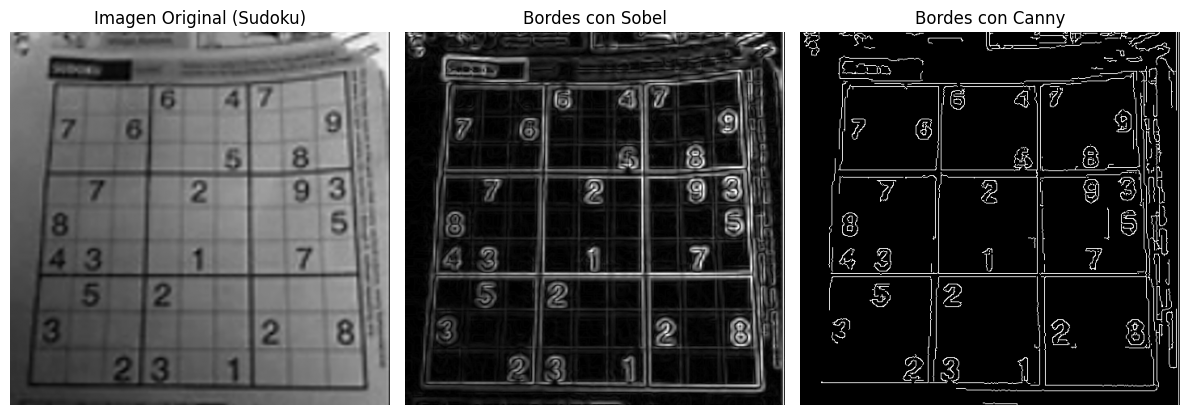

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar imagen ---
img_path = 'fig/Notebook/Sudoku.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"No se encontró la imagen: {img_path}")

# --- Filtro Sobel ---
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_combined = cv2.convertScaleAbs(sobel_combined)

# --- Filtro Canny ---
edges_canny = cv2.Canny(img, 50, 100)

# --- Mostrar resultados ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

titles = [
    "Imagen Original (Sudoku)",
    "Bordes con Sobel",
    "Bordes con Canny"
]
images = [img, sobel_combined, edges_canny]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()
